In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
movie=pd.read_csv('https://raw.githubusercontent.com/rajeevratan84/datascienceforbusiness/refs/heads/master/MoviesOnStreamingPlatforms_updated.csv')


In [ ]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16744 entries, 0 to 16743
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       16744 non-null  int64  
 1   ID               16744 non-null  int64  
 2   Title            16744 non-null  object 
 3   Year             16744 non-null  int64  
 4   Age              7354 non-null   object 
 5   IMDb             16173 non-null  float64
 6   Rotten Tomatoes  5158 non-null   object 
 7   Netflix          16744 non-null  int64  
 8   Hulu             16744 non-null  int64  
 9   Prime Video      16744 non-null  int64  
 10  Disney+          16744 non-null  int64  
 11  Type             16744 non-null  int64  
 12  Directors        16018 non-null  object 
 13  Genres           16469 non-null  object 
 14  Country          16309 non-null  object 
 15  Language         16130 non-null  object 
 16  Runtime          16152 non-null  float64
dtypes: float64(2

Data cleaning

In [ ]:
movie['IMDb'].fillna(5.902751,inplace=True	)  #used mean to fill null

<ipython-input-4-c56a1a78376d>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie['IMDb'].fillna(5.902751,inplace=True	)  #used mean to fill null


In [ ]:
movie['Runtime'].median()
movie['Runtime'].fillna(100.0,inplace=True) #used median to fill null

<ipython-input-5-01c9d7c4268d>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie['Runtime'].fillna(100.0,inplace=True) #used median to fill null


Unnamed: 0 is just an index column

In [ ]:
movie.drop(columns=['Unnamed: 0'], inplace=True)
movie.drop(columns=['Type'],inplace=True)

In [ ]:
movie['Age']=movie['Age'].replace({'all':'0'}) #This replaces any occurrence of the string 'all' in the Age column with the string '0'
movie['Age']=movie['Age'].str.extract('(\d+)',expand=False) #str.extract('(\d+)'): Extracts numeric characters (digits) from each entry in the Age column using a regular expression \d+ Ensures that the result is a Series instead of a DataFrame.
movie['Age']=movie['Age'].astype('float').astype('Int64')  #Ensures that the Age column has a proper integer data type.


In [ ]:
movie['Age']=movie['Age'].fillna(13.0)

used unknown to fill missing values in directors column

In [ ]:
movie['Directors']=movie['Directors'].fillna('unknown')

In [ ]:
movie['Genres']=movie['Genres'].fillna('unknown')

In [ ]:
movie['Country']=movie['Country'].fillna('unknown')

In [ ]:
movie['Language']=movie['Language'].fillna('unknown')

In [ ]:
movie['Rotten Tomatoes']=movie['Rotten Tomatoes'].str.replace('%','')
movie.rename(columns={'Rotten Tomatoes':'Rotten Tomatoes(%)'},inplace=True)


In [ ]:
movie['Rotten Tomatoes(%)']=movie['Rotten Tomatoes(%)'].astype(float)


In [ ]:
movie['Rotten Tomatoes(%)'].fillna(65.42,inplace=True)
movie['Rotten Tomatoes(%)']=movie['Rotten Tomatoes(%)'].astype(int)/10

<ipython-input-15-c6726703169e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie['Rotten Tomatoes(%)'].fillna(65.42,inplace=True)


In [ ]:
movie.info() # to check if any data is missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16744 entries, 0 to 16743
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  16744 non-null  int64  
 1   Title               16744 non-null  object 
 2   Year                16744 non-null  int64  
 3   Age                 16744 non-null  Int64  
 4   IMDb                16744 non-null  float64
 5   Rotten Tomatoes(%)  16744 non-null  float64
 6   Netflix             16744 non-null  int64  
 7   Hulu                16744 non-null  int64  
 8   Prime Video         16744 non-null  int64  
 9   Disney+             16744 non-null  int64  
 10  Directors           16744 non-null  object 
 11  Genres              16744 non-null  object 
 12  Country             16744 non-null  object 
 13  Language            16744 non-null  object 
 14  Runtime             16744 non-null  float64
dtypes: Int64(1), float64(3), int64(6), object(5)
memory u

Feature Engineering

In [ ]:
platforms=['Netflix','Hulu','Prime Video','Disney+']
movie['countplatform']=movie[platforms].sum(axis=1)

In [ ]:
movie['runtime_category'] = pd.cut(
    movie['Runtime'],
    bins=[0,40,90,float('inf')],
    labels=['Short','Medium','Long']
)


In [ ]:
# Extract release decade
movie['decade'] = (movie['Year'] // 10) * 10

PLATFORM ANALYSIS

1.How many movies are available on each streaming platform

In [ ]:
netflix=movie['Netflix'].sum()
print(f'movies on netflix--',netflix)
hulu=movie['Hulu'].sum()
print(f'movies on hulu--',hulu)
prime=movie['Prime Video'].sum()
print(f'movies on prime--',prime)
disney=movie['Disney+'].sum()
print(f'movies on disney--',disney)


movies on netflix-- 3560
movies on hulu-- 903
movies on prime-- 12354
movies on disney-- 564


Check if Prime Video has more representation in niche or diverse genres.

In [ ]:
prime_movies = movie[movie['Prime Video'] == 1]
prime_genres_split = prime_movies['Genres'].str.split(',').explode()
prime_genre_counts = prime_genres_split.value_counts()
netflix_movies = movie[movie['Netflix'] == 1]
netflix_genres_split = netflix_movies['Genres'].str.split(',').explode()
netflix_genre_counts = netflix_genres_split.value_counts()
hulu_movies = movie[movie['Hulu'] == 1]
hulu_genres_split = hulu_movies['Genres'].str.split(',').explode()
hulu_genre_counts = hulu_genres_split.value_counts()
disney_movies = movie[movie['Disney+'] == 1]
disney_genres_split = disney_movies['Genres'].str.split(',').explode()
disney_genre_counts = disney_genres_split.value_counts()


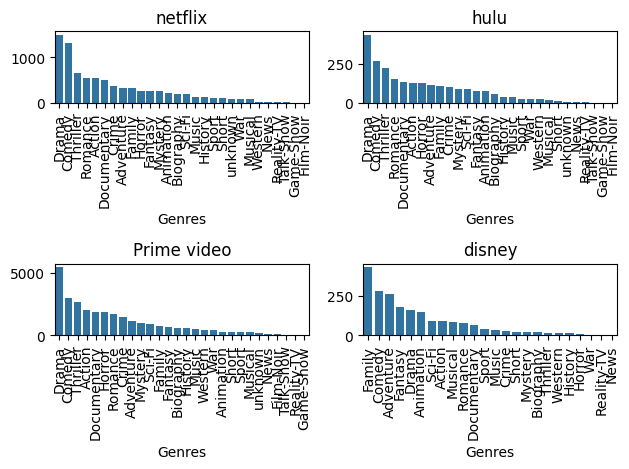

In [ ]:
figsize=(20,20)
plt.subplot(2,2,1)
sns.barplot(x=netflix_genre_counts.index,y=netflix_genre_counts.values)
plt.xticks(rotation=90)
plt.title('netflix')
plt.subplot(2,2,2)
sns.barplot(x=hulu_genre_counts.index,y=hulu_genre_counts.values)
plt.xticks(rotation=90)
plt.title('hulu')
plt.subplot(2,2,3)
sns.barplot(x=prime_genre_counts.index,y=prime_genre_counts.values)
plt.xticks(rotation=90)
plt.title('Prime video')
plt.subplot(2,2,4)
sns.barplot(x=disney_genre_counts.index,y=disney_genre_counts.values)
plt.xticks(rotation=90)
plt.title('disney')
plt.tight_layout()
plt.show()

Create a piechart to compare how the platforms rank for drama genre.

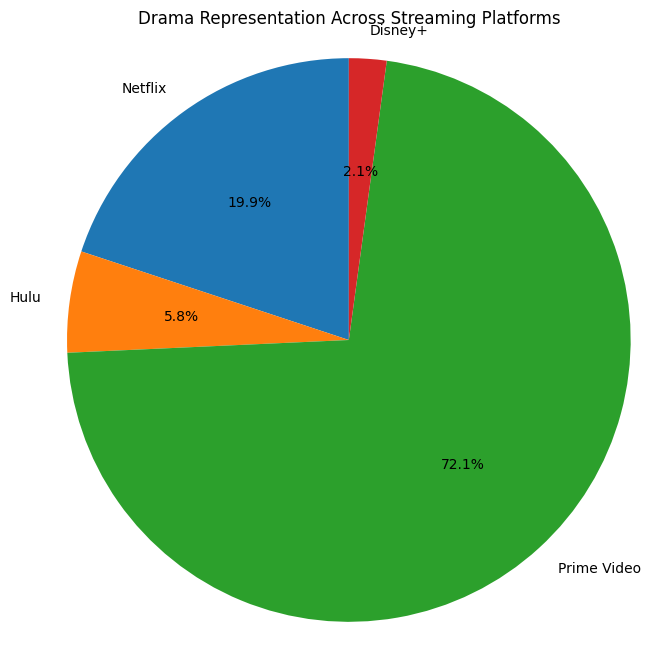

In [ ]:
# Calculate Drama representation on each platform
platform_drama_counts = {}
for platform in platforms:
    platform_movies = movie[movie[platform] == 1]
    platform_genres_split = platform_movies['Genres'].str.split(',').explode()
    platform_drama_counts[platform] = platform_genres_split.str.contains('Drama').sum()

# Create a pie chart
labels = platform_drama_counts.keys()
sizes = platform_drama_counts.values()

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Drama Representation Across Streaming Platforms')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


Prime Video dominates the Drama genre with the highest share, accounting for 72.1% of the total Drama content across platforms. platforms like Prime Video leverage the Drama genre extensively to attract audiences.

based on decade ,count the number of movies on each platforms

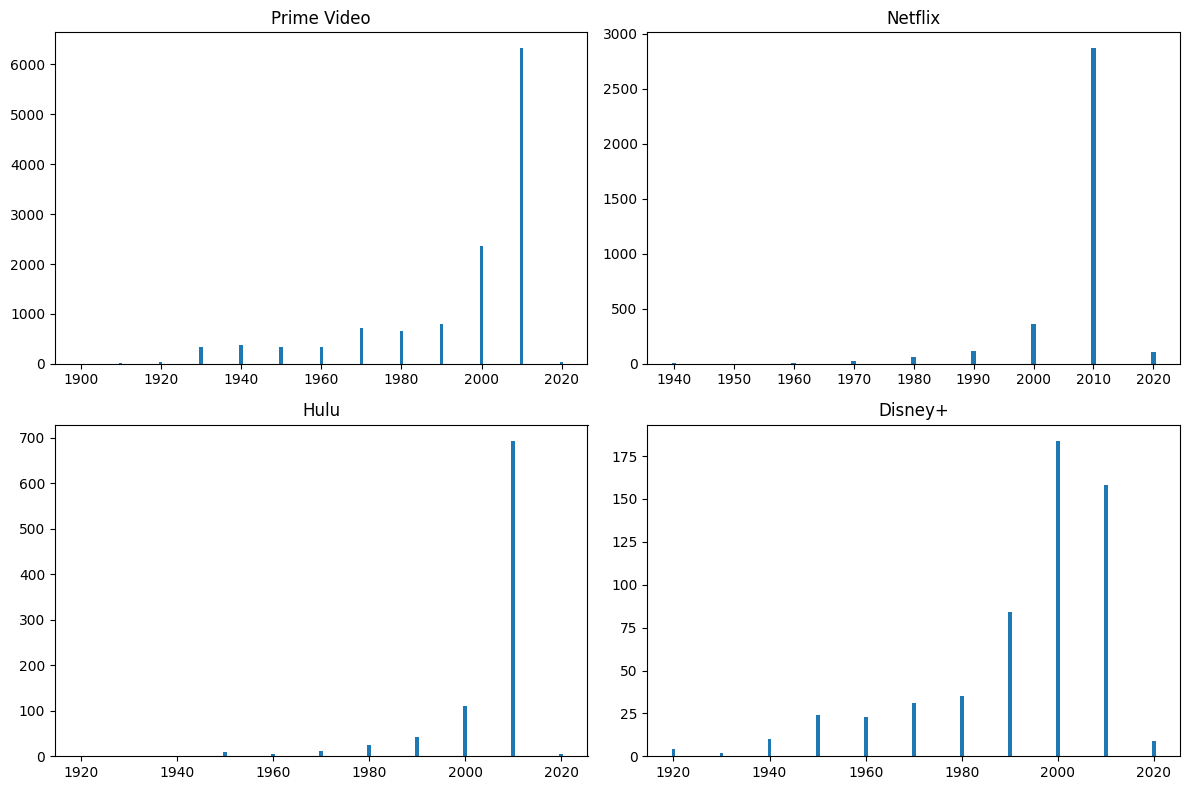

In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # Create a 2x2 grid of subplots

# Prime Video
prime_video_movies = movie[movie['Prime Video'] == 1]
grp_obj = prime_video_movies.groupby(['decade'])
group_sizes = grp_obj.size()
axes[0, 0].bar(group_sizes.index, group_sizes.values)
axes[0, 0].set_title('Prime Video')

# Netflix
prime_video_movies = movie[movie['Netflix'] == 1]
grp_obj = prime_video_movies.groupby(['decade'])
group_sizes = grp_obj.size()
axes[0, 1].bar(group_sizes.index, group_sizes.values)
axes[0, 1].set_title('Netflix')

# Hulu
prime_video_movies = movie[movie['Hulu'] == 1]
grp_obj = prime_video_movies.groupby(['decade'])
group_sizes = grp_obj.size()
axes[1, 0].bar(group_sizes.index, group_sizes.values)
axes[1, 0].set_title('Hulu')

# Disney+
prime_video_movies = movie[movie['Disney+'] == 1]
grp_obj = prime_video_movies.groupby(['decade'])
group_sizes = grp_obj.size()
axes[1, 1].bar(group_sizes.index, group_sizes.values)
axes[1, 1].set_title('Disney+')
plt.tight_layout()

from above subplot it is clear that movies from 1910 have been added into Prime video which is one of the reason for having more movies in its platform

Conclusion:
Prime Video's extensive movie library is driven by a combination of:

A large collection of Drama movies.
A significant number of older movies spanning multiple decades

AGE GROUP WITH PLATFORM

Checking Number of Movies in a given Age group

Age
0       843
7      1462
13    10645
16      320
18     3474
dtype: int64


Text(0, 0.5, 'Number of Movies')

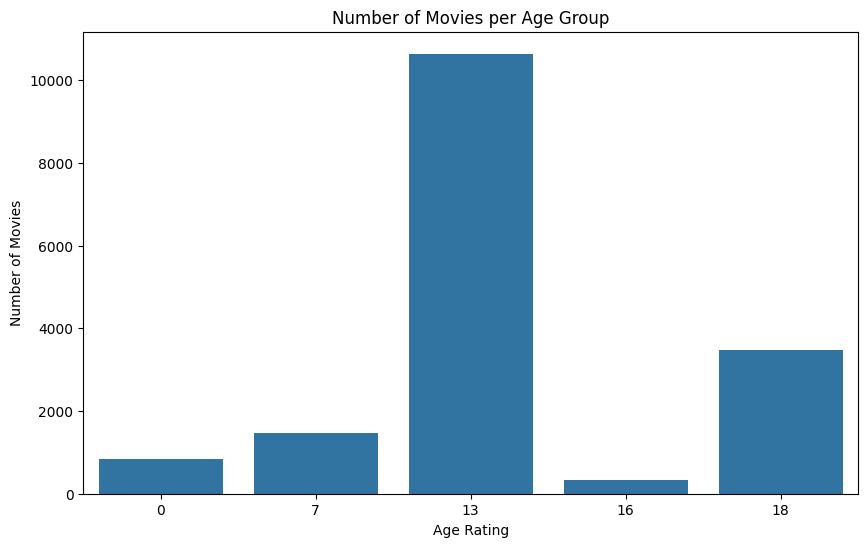

In [ ]:
age_group_counts = movie.groupby('Age').size()
print(age_group_counts)
plt.figure(figsize=(10, 6))
sns.countplot(x='Age', data=movie)
plt.title('Number of Movies per Age Group')
plt.xlabel('Age Rating')
plt.ylabel('Number of Movies')




Analyzing number of Movies in speific age group in each platform

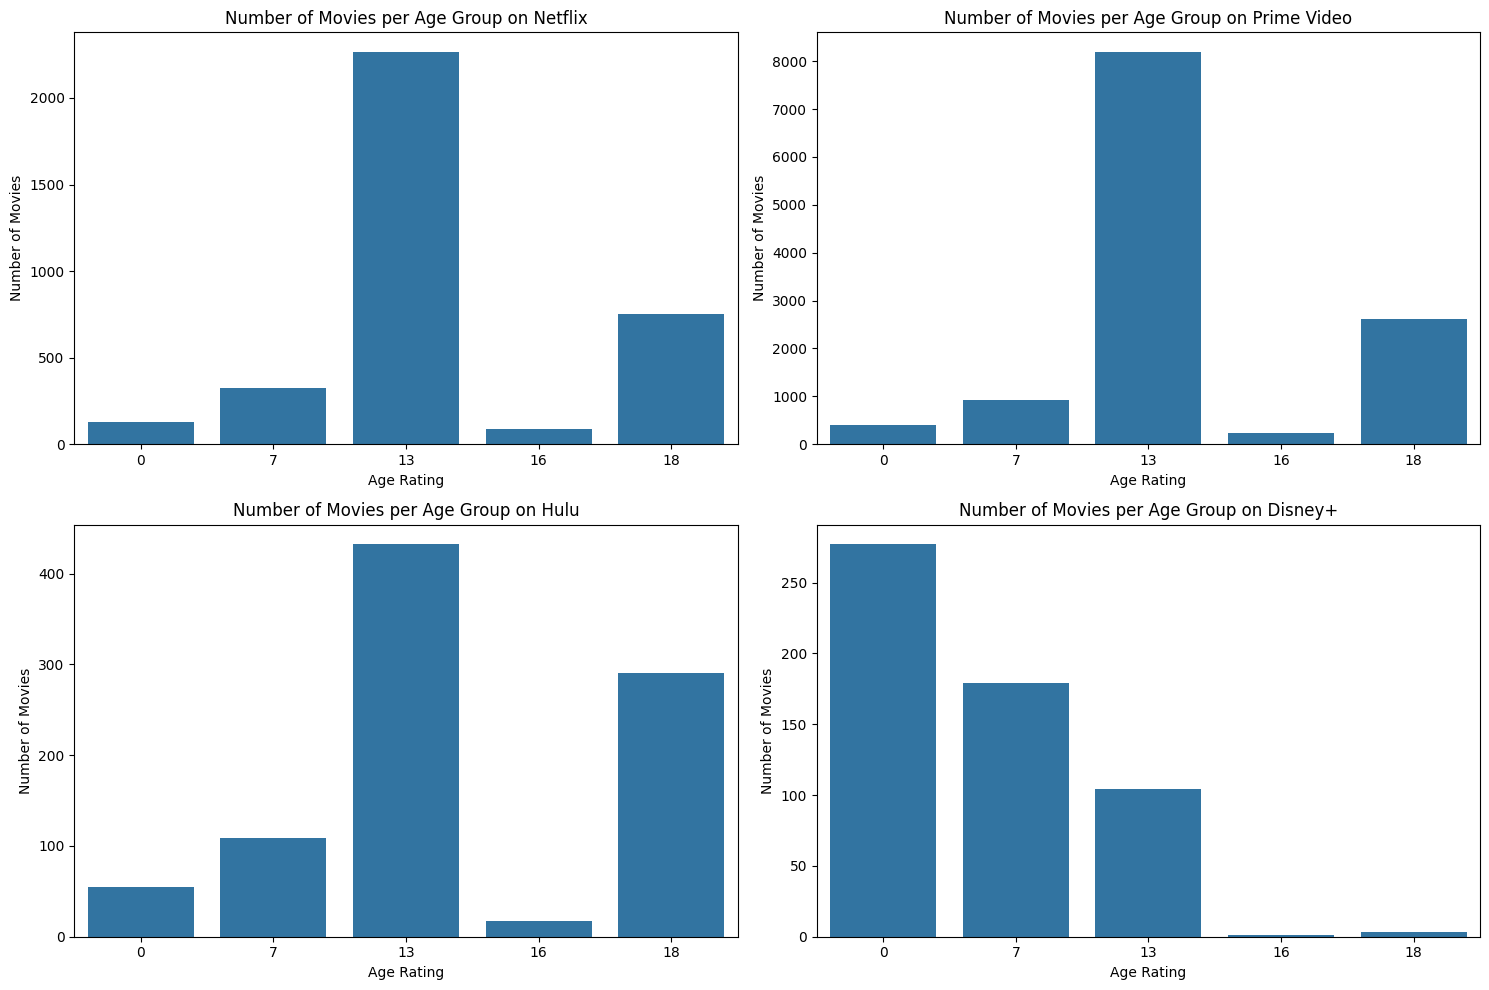

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))  # Create a 2x2 grid of subplots
sns.countplot(x='Age', data=movie[movie['Netflix'] == 1], ax=axes[0, 0])
axes[0, 0].set_title('Number of Movies per Age Group on Netflix')
axes[0, 0].set_xlabel('Age Rating')
axes[0, 0].set_ylabel('Number of Movies')

# Prime Video
sns.countplot(x='Age', data=movie[movie['Prime Video'] == 1], ax=axes[0, 1])
axes[0, 1].set_title('Number of Movies per Age Group on Prime Video')
axes[0, 1].set_xlabel('Age Rating')
axes[0, 1].set_ylabel('Number of Movies')

# Hulu
sns.countplot(x='Age', data=movie[movie['Hulu'] == 1], ax=axes[1, 0])
axes[1, 0].set_title('Number of Movies per Age Group on Hulu')
axes[1, 0].set_xlabel('Age Rating')
axes[1, 0].set_ylabel('Number of Movies')

# Disney+
sns.countplot(x='Age', data=movie[movie['Disney+'] == 1], ax=axes[1, 1])
axes[1, 1].set_title('Number of Movies per Age Group on Disney+')
axes[1, 1].set_xlabel('Age Rating')
axes[1, 1].set_ylabel('Number of Movies')


plt.tight_layout()

Observation:Most of the movies streamed on Disney+ is suitable for all age group. We can see that, as per the above plot only negligible 18+ movies are listed in the Disney+

In [ ]:
grp_obj = netflix_movies.groupby(['Netflix'])
netflix_movie_mean = grp_obj['IMDb'].mean()
print(netflix_movie_mean)
grp_obj = hulu_movies.groupby(['Hulu'])
hulu_movie_mean = grp_obj['IMDb'].mean()
print(hulu_movie_mean)
grp_obj = prime_movies.groupby(['Prime Video'])
primevideo_movie_mean = grp_obj['IMDb'].mean()
print(primevideo_movie_mean)
grp_obj = disney_movies.groupby(['Disney+'])
disney_movie_mean = grp_obj['IMDb'].mean()
print(disney_movie_mean)





Netflix
1    6.241355
Name: IMDb, dtype: float64
Hulu
1    6.135249
Name: IMDb, dtype: float64
Prime Video
1    5.77567
Name: IMDb, dtype: float64
Disney+
1    6.44043
Name: IMDb, dtype: float64


Disney+ has the highest-rated movies on average with an IMDb rating of 6.44

conclusion:Disney+ predominantly caters to a family-friendly audience, with the majority of its content being suitable for all age groups. The platform’s focus on family-oriented and universally accessible content likely contributes to its high average IMDb rating of 6.44

average IMDb score by decade and Age Preference

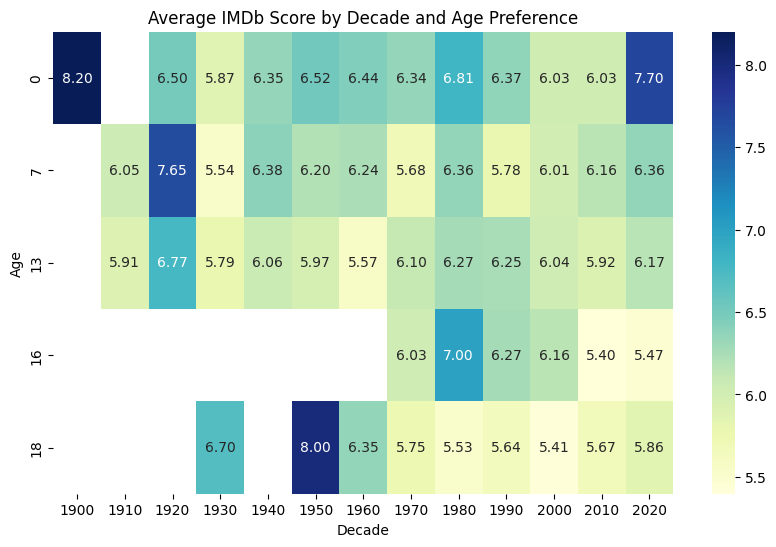

In [ ]:
decade_age_imdb = movie.groupby(['decade', 'Age'])['IMDb'].mean().reset_index()
decade_age_imdb_pivot = decade_age_imdb.pivot(index="Age", columns="decade", values="IMDb")
# Plot heatmap
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.heatmap(decade_age_imdb_pivot, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title('Average IMDb Score by Decade and Age Preference')
plt.xlabel('Decade')
plt.ylabel('Age')
plt.show()

The heatmap reveals that family-friendly movies (age 0) receive high ratings across various decades, suggesting that movies suitable for all ages have a broad appeal.

What trends can be observed in movie production over the decades?

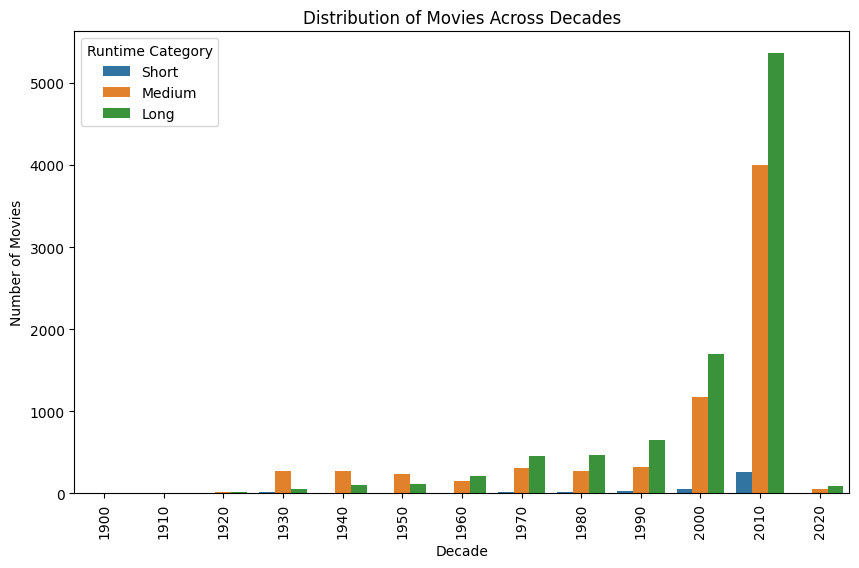

In [ ]:
decade_counts = movie['decade'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.countplot(x='decade', data=movie, hue='runtime_category')
plt.xticks(rotation=90)
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movies Across Decades")
plt.legend(title='Runtime Category')

From the graph, it appears that between 1930 and 1960, the majority of movies produced fell under the medium runtime category. This could be due to several factors, such as technological limitations, shorter storytelling styles, or economic factors that influenced movie production during this period. However, post-1960, there is a noticeable increase in the number of long runtime movies produced, which might be attributed to the evolution of filmmaking techniques and changes in audience preferences.As filmmaking technology improved, directors and producers were able to create more complex, immersive stories that demanded longer runtimes

Use the Age and runtime_category columns to understand audience preferences for different age groups and runtimes.

runtime_category  Short  Medium  Long
Age                                  
0                    43     444   356
7                    26     528   908
13                  325    4756  5564
16                    3     152   165
18                   33    1213  2228


<ipython-input-30-533e07314de8>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_runtime_counts = movie.groupby(['Age', 'runtime_category']).size().unstack(fill_value=0)


Text(120.72222222222221, 0.5, 'Age Rating')

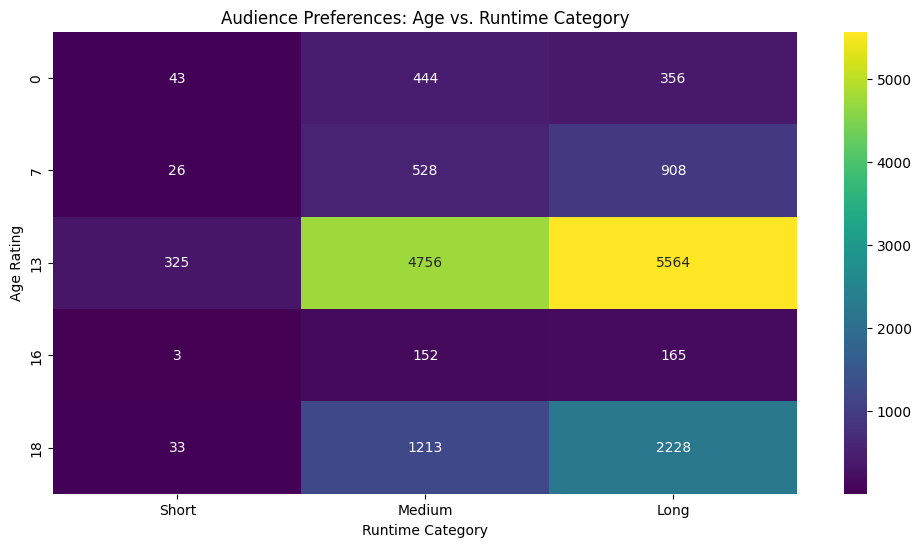

In [ ]:

age_runtime_counts = movie.groupby(['Age', 'runtime_category']).size().unstack(fill_value=0)
print(age_runtime_counts)

plt.figure(figsize=(12, 6))
sns.heatmap(age_runtime_counts, annot=True, fmt='d', cmap='viridis')
plt.title('Audience Preferences: Age vs. Runtime Category')
plt.xlabel('Runtime Category')
plt.ylabel('Age Rating')


For younger audiences (Age = 0 and 7): The preference for Medium runtimes is clear, with a balanced presence of Short and Long movies for the all-ages category.
For mature audiences (Age = 16 and 18+): The dominance of Long runtimes confirms the preference for in-depth and complex storytelling among these groups..

Dominant Languages:
Language
English     13233
Spanish       872
French        799
Hindi         731
unknown       614
German        483
Italian       440
Mandarin      352
Japanese      317
Russian       222
Name: count, dtype: int64

Underrepresented Languages:
Language
Spanish Sign Language    1
Cornish                  1
Papiamento               1
Tupi                     1
Haryanvi                 1
Maltese                  1
Hakka                    1
Scots                    1
Ewe                      1
Algonquin                1
Name: count, dtype: int64


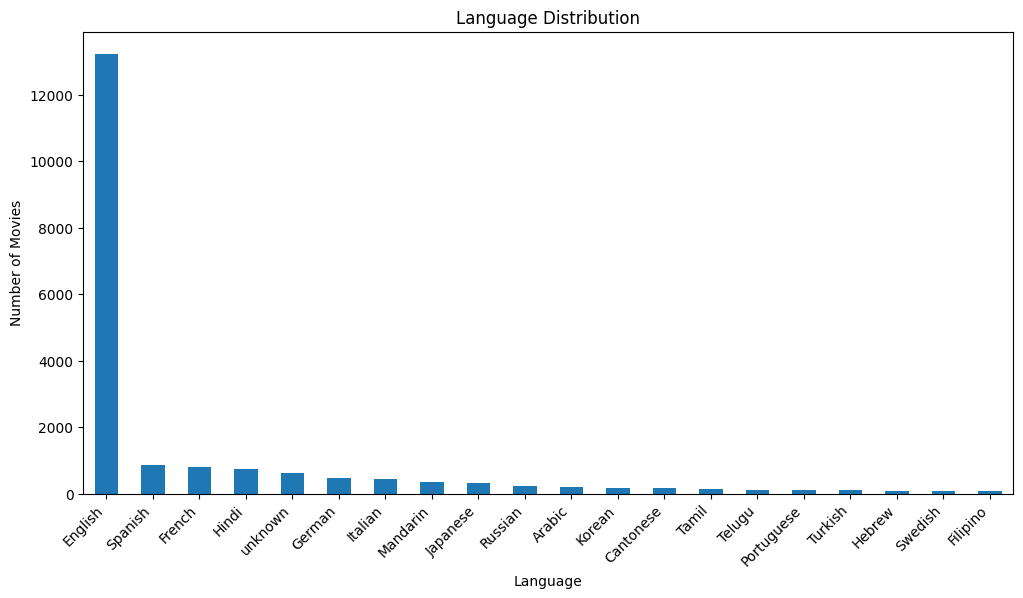


Dominant Countries:
Country
United States     10486
United Kingdom     1713
India              1157
Canada             1117
France              741
Germany             498
unknown             435
Italy               417
Spain               329
Australia           321
Name: count, dtype: int64

Underrepresented Countries:
Country
Bahrain                             1
Chad                                1
The Democratic Republic Of Congo    1
Swaziland                           1
Moldova                             1
Kosovo                              1
U.S. Virgin Islands                 1
Guam                                1
Oman                                1
Botswana                            1
Name: count, dtype: int64


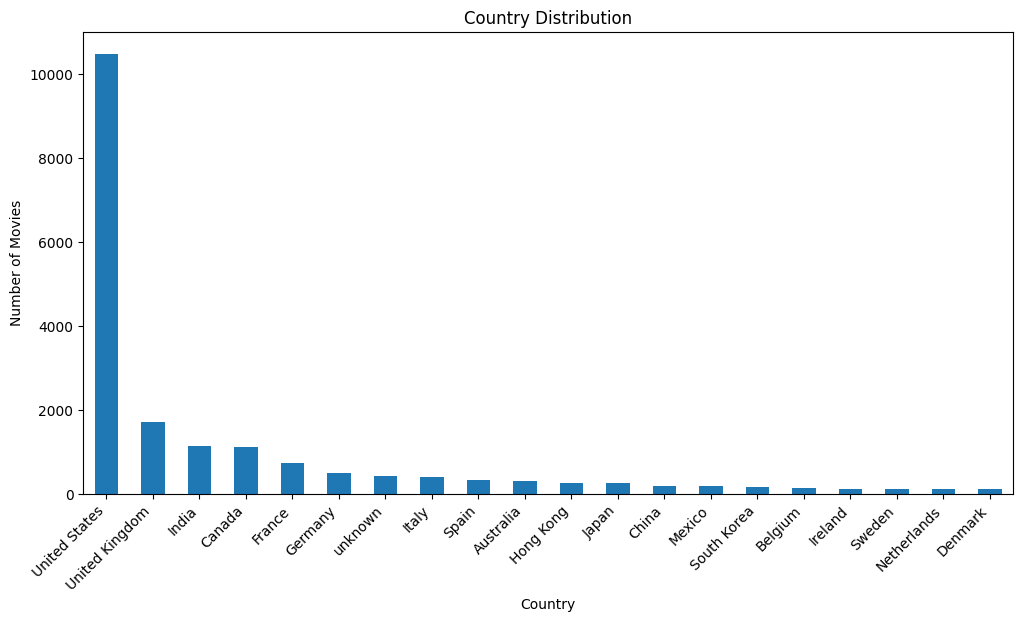

In [ ]:
language_counts = movie['Language'].str.split(',').explode().value_counts()
print("Dominant Languages:")
print(language_counts.head(10))

print("\nUnderrepresented Languages:")
print(language_counts.tail(10))


plt.figure(figsize=(12, 6))
language_counts.head(20).plot(kind='bar')
plt.title('Language Distribution')
plt.xlabel('Language')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.show()


country_counts = movie['Country'].str.split(',').explode().value_counts()

print("\nDominant Countries:")
print(country_counts.head(10))

print("\nUnderrepresented Countries:")
print(country_counts.tail(10))

plt.figure(figsize=(12, 6))
country_counts.head(20).plot(kind='bar')
plt.title('Country Distribution')
plt.xlabel('Country')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.show()

CONCLUSION:Streaming platforms can tap into regional markets by promoting localized content.
Marketing efforts can target these underrepresented areas, emphasizing inclusion and diversity.
Partnerships with regional filmmakers can help produce and distribute content that resonates with specific demographics.

1. Platform Distribution: Prime Video has the most extensive movie library, whereas Disney+ has the smallest movie library
2.Age Ratings: A significant portion of movies is suitable for ages like young audience  in disney+ and negligible



In [ ]:
movie_to_csv = movie.to_csv('movie_modified.csv')